In [32]:
# Installation (si nécessaire, à exécuter une seule fois)
!pip install seaborn matplotlib pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Importation du dataset
df = pd.read_csv("../data/mesures_capteurs.csv")

In [35]:
# Apercu des premières lignes du dataset
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [36]:
# Dimensions du dataset
print(df.shape)

(605, 9)


In [37]:
# Informations générales (types, valeurs manquantes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [38]:
# Statistiques descriptives
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [39]:
# Vérification des valeurs manquantes
df.isnull().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

# Partie 1 - Distribution d'une variable avec histplot() 
1) Afficher la distributions des temperatures

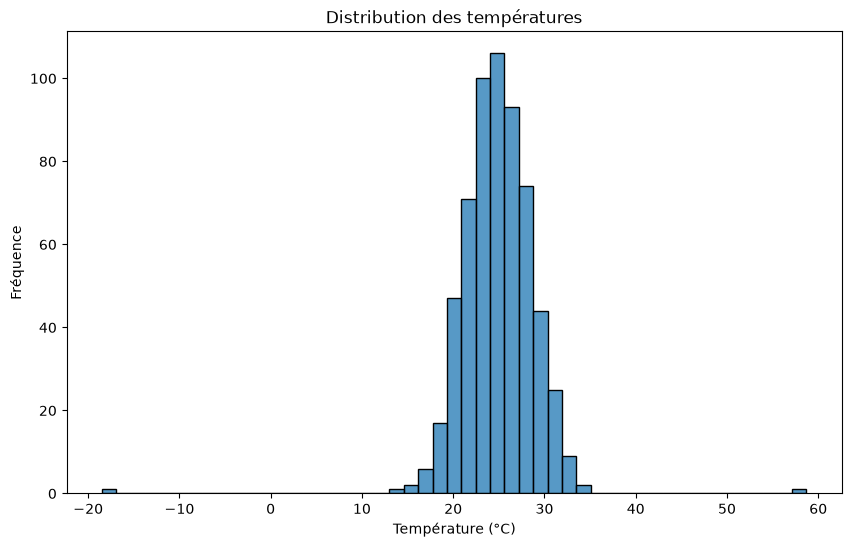

In [45]:
# Affichage des graphiques directement dans le notebook

%matplotlib inline


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

2) Autour de quelle valeur les températures sont concentrées ? 

Les temperatures sont concentrees entre 20°C et 30°C avec un pic autour de 24-25°

3) La distribution semble-t-elle symétrique ? 

La distribution semble globalement symetrique : elle augmente progressivement jusqu'à un sommet vers 24-25°C, puis redescend de façon similaire.


4) Existe-t-il des valeurs extrêmes ? 
 
 On peut observer des valeurs extremes : environ -18°C et 58°C, ces valeurs sont isolees du reste de la distribution

5) Modifier le nombre de classes 

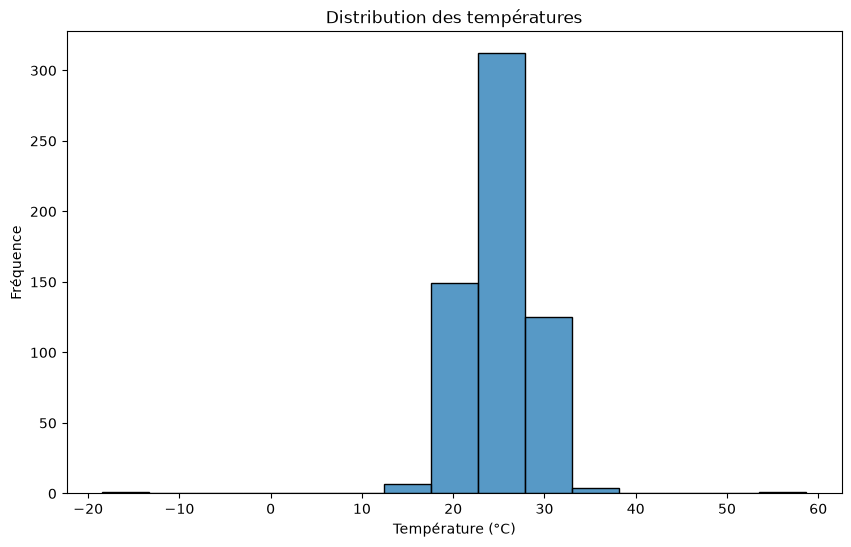

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature", bins=15)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

# bins permet de definir le nombre de classes pour l'histogramme. Plus le nombre de bins est élevé, plus l'histogramme sera détaillé.

6) Afficher la distribution des températures par bâtiment 

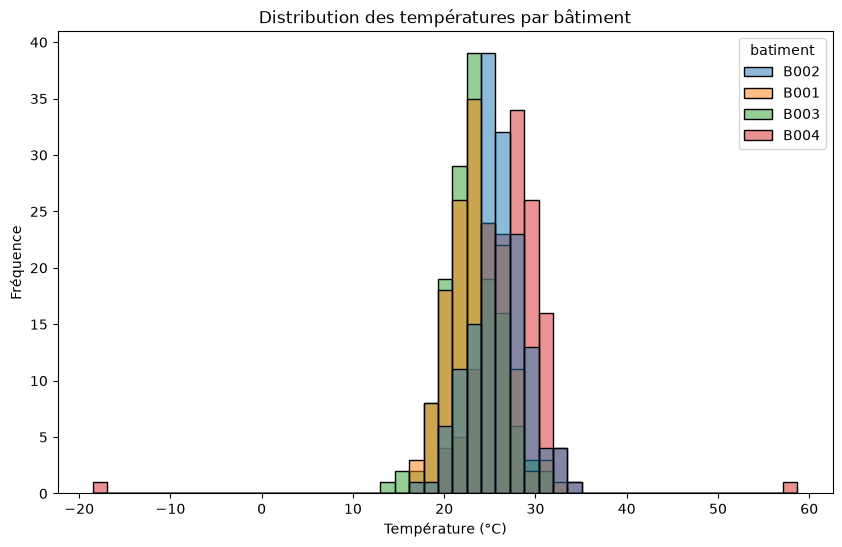

In [47]:
# hue permet de separer et colorer l'histogramme selon une variable categorielle,

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="temperature", hue="batiment")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()


Les températures sont globalement homogènes entre bâtiments, avec une variation modérée du pic selon le bâtiment, et une anomalie isolée sur B004.

# Partie 2 - Distribution d'une variable avec kdeplot() 

1) Afficher la distribution des températures 

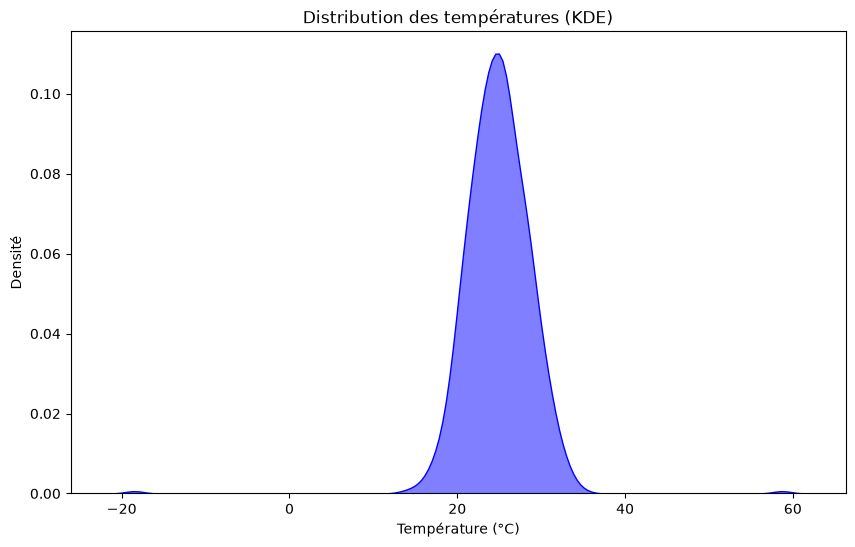

In [ ]:
# kdeplot affiche une estimation de densite (courbe lissee) de la distribution,
# plus lisible qu'un histogramme pour voir la forme generale de la repartition.
# fill=True permet de remplir la zone sous la courbe, alpha=0.5 ajuste la transparence, color="blue" change la couleur de la courbe.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature",fill=True, alpha=0.5, color="blue")
plt.title("Distribution des températures (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

2) Afficher la distribution des températures par bâtiment 

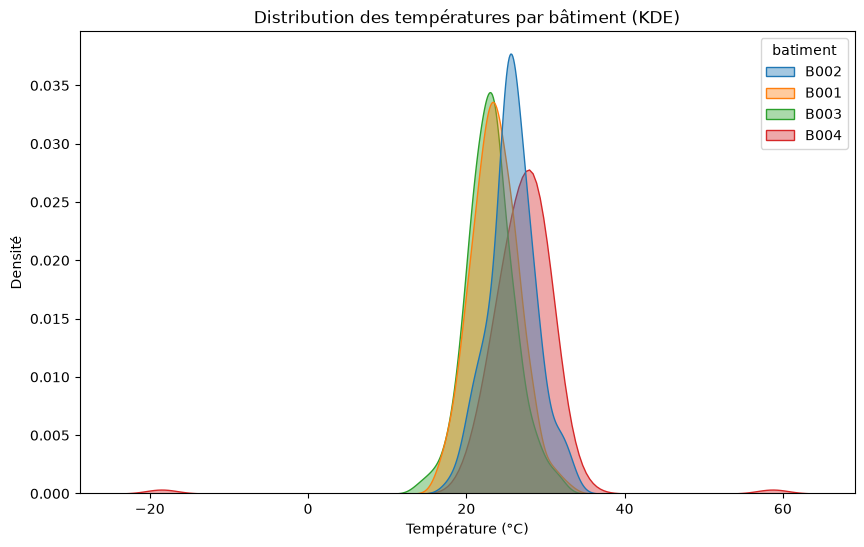

In [55]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, alpha=0.4)
plt.title("Distribution des températures par bâtiment (KDE)")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")
plt.show()

**Observations (KDE par bâtiment) :**

- Chaque bâtiment a une température moyenne différente : B003 et B001 sont plutôt
  frais (~22-23°C), B002 est moyen (~24-25°C), et B004 est le plus chaud (~27-28°C).
- B002 a des températures très stables (courbe haute et fine).
  B004 a des températures plus variables (courbe basse et étalée).
- B004 est aussi le seul bâtiment avec des valeurs extrêmes (proches de -20°C et 60°C).

# Partie 3 – Distribution d'une variable avec boxplot() 

1) Afficher la distribution des températures 

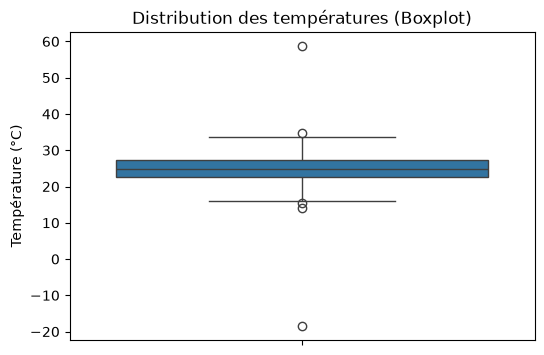

In [63]:
# boxplot affiche la mediane, les quartiles et les valeurs extremes (outliers)
# sous forme de boite a moustaches.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y="temperature")
plt.title("Distribution des températures (Boxplot)")
plt.ylabel("Température (°C)")
plt.show()

2) Afficher la distribution des températures par bâtiment 

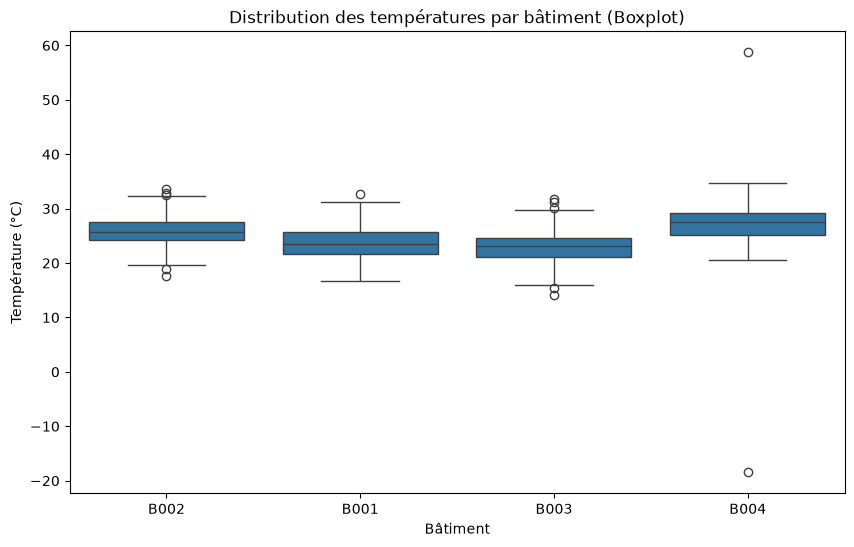

In [64]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Distribution des températures par bâtiment (Boxplot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) Pour chaque batiment
    a) Quelle est la mediane
        B002 a environ 25°C comme mediane
        ---
        B001 a environ 23°C comme mediane
        ---
        B003 a environ 22°C comme mediane
        ---
        B004 a environ 27°C comme mediane
    b) Quelle est la dispersion
        B002 a une dispersion moderee (boite de taille moyenne)
        ---
        B001 a une dispersion faible (boite compacte)
        ---
        B003 a une dispersion faible (boite compacte)
        ---
        B004 a une dispersion forte (boite la plus large, de 20°C a 34°C)
    c) Les valeurs extremes
        B002 a des valeurs extremes autour de 18°C et 33°C
        ---
        B001 a une valeur extreme legere autour de 31°C
        ---
        B003 a plusieurs valeurs extremes autour de 15°C, 31°C et 32°C
        ---
        B004 a deux valeurs extremes tres marquees autour de -18°C et 58°C

    4) quels bâtiments ont les valeurs les plus extrêmes ?

        B004 a les valeurs les plus extremes avec des outliers autour de -18°C et 58°C.
        Les autres batiments (B001, B002, B003) ont aussi des valeurs extremes mais bien beaucoup moins marquees

# Partie 4 – Distribution d'une variable avec violinplot()

1) fficher la distribution des températures 

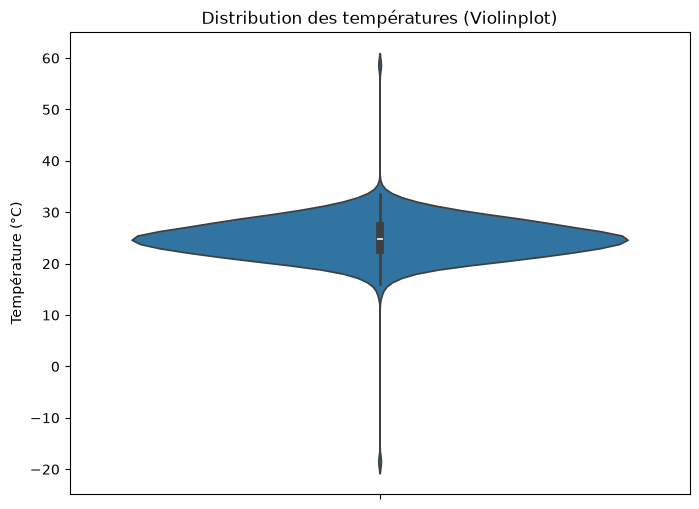

In [ ]:
# violinplot combine le boxplot et le kdeplot : il montre la mediane, les quartiles
# et la forme de la distribution (densite) en meme temps.
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, y="temperature")
plt.title("Distribution des températures (Violinplot)")
plt.ylabel("Température (°C)")
plt.show()

2) Afficher la distribution des températures par bâtiment 

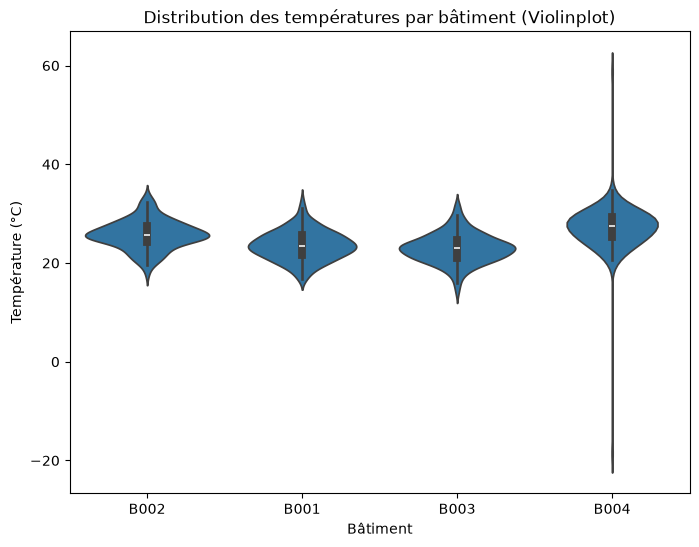

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df,x="batiment", y="temperature")
plt.title("Distribution des températures par bâtiment (Violinplot)")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")
plt.show()

3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box plot ? 

Le violin permet de visualiser la densité (la concentration) des températures à chaque niveau, alors que le boxplot ne donne que des points-repères (médiane, quartiles,outliers) sans montrer comment les données sont réparties entre ces points

# Partie 5 – Comptage des catégories avec countplot() 

1) Afficher le nombre de mesures par état  

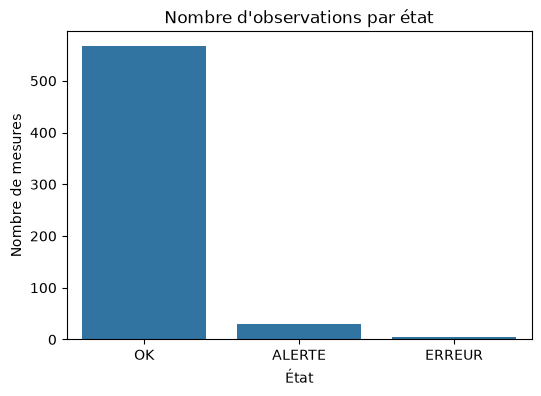

In [74]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="etat")
plt.title("Nombre d'observations par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.show()

# On voit ici que "ok" concentre beaucoup plus
# d'observations que "alert" qui a peu d'observations et "erreur" en a encore moins.


2) Afficher le nombre de mesures par bâtiment

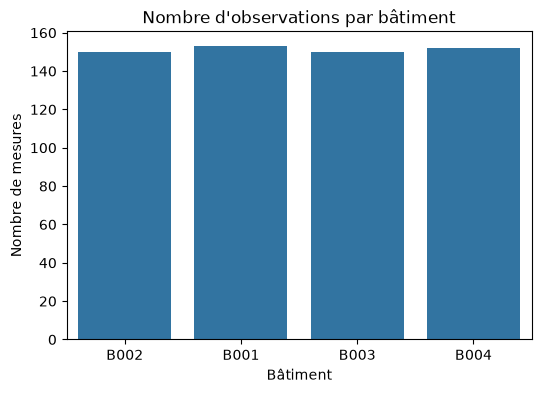

In [75]:
# Les 4 bâtiments ont un nombre d'observations similaire (~145-150 chacun),
# ce qui garantit des comparaisons équitables entre eux.
# Cela confirme aussi que les valeurs extrêmes de B004 sont des cas isolés,
# et non le signe d'un volume de données anormal pour ce bâtiment.

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="batiment")
plt.title("Nombre d'observations par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")
plt.show()

3) Afficher les états des capteurs par bâtiment pour identifier  


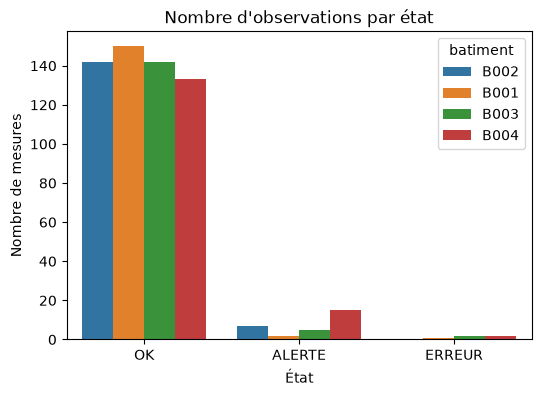

In [76]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="etat", hue="batiment")
plt.title("Nombre d'observations par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")
plt.show()

a) le bâtiment ayant le plus de mesures en état OK 
    On peut observer que le batiment B001 a plus de mesures en etat OK avec environ 130
b) celui ayant le plus de mesures en ALERTE 
    B004 est le batiment avec le plus de mesures en ALERTE
c) celui ayant le plus de mesures en ERREUR. 
    les batiments B004 et B003 semblent etre au meme niveau donc ils ont plus de mesures en ERREUR

# Partie 6 – Relation entre deux variables avec scatterplot()

1) Etudier graphiquement la relation entre température et consommation 

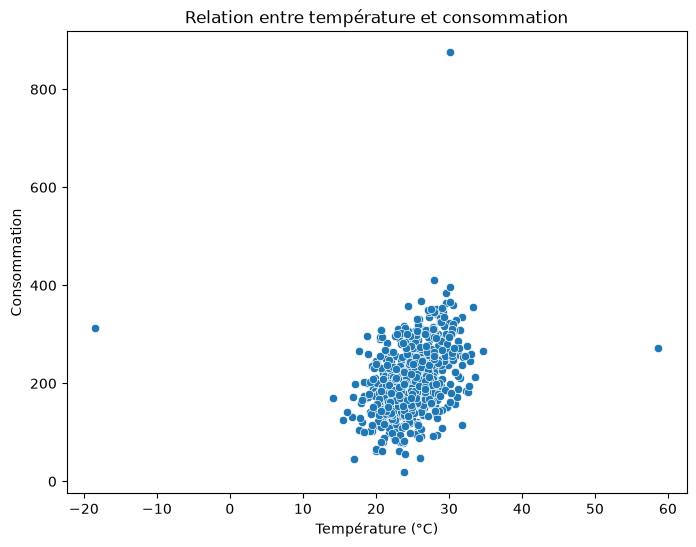

In [ ]:
#On observe un nuage de points assez dense entre 15°C et 35°C, avec une legere
#tendance : la consommation semble augmenter un peu avec la temperature, mais la
#relation n'est pas tres nette (le nuage est assez disperse). On retrouve aussi
#les deux valeurs extremes deja identifiees (-18°C et 58°C), qui sont isolees
#u reste du nuage de points.

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()

2) Etudier graphiquement la relation entre température et consommation par bâtiment

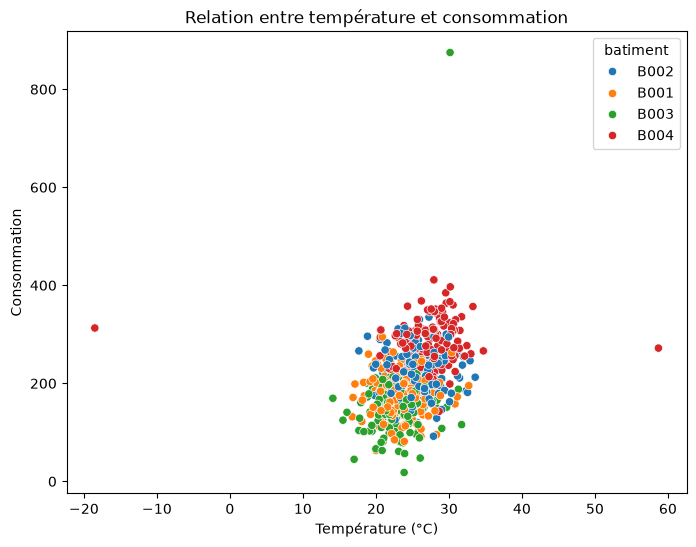

In [ ]:
# On peut observer que B003  a des consommations moyennement plus basses que les autres 
# mais il a aussi un pic de consommation quisort du lot avec environ 850 de consommation. 
# On peut observer que B004 a genreralement des temperatures et consommations plus elevees par rapport aux autres batiments.

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="temperature", y="consommation" ,hue="batiment")
plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")
plt.show()